Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


--- 🚀 Training Evolution Memory (Accuracy Mode) ---
Epoch 1/10 | Train: 0.4528 | Val: 0.0050
Epoch 2/10 | Train: 0.0038 | Val: 0.0016
Epoch 3/10 | Train: 0.0014 | Val: 0.0008
Epoch 4/10 | Train: 0.0009 | Val: 0.0004
Epoch 5/10 | Train: 0.0004 | Val: 0.0002
Epoch 6/10 | Train: 0.0003 | Val: 0.0002
Epoch 7/10 | Train: 0.0002 | Val: 0.0002
Epoch 8/10 | Train: 0.0002 | Val: 0.0001
Epoch 9/10 | Train: 0.0001 | Val: 0.0001
Epoch 10/10 | Train: 0.0001 | Val: 0.0001


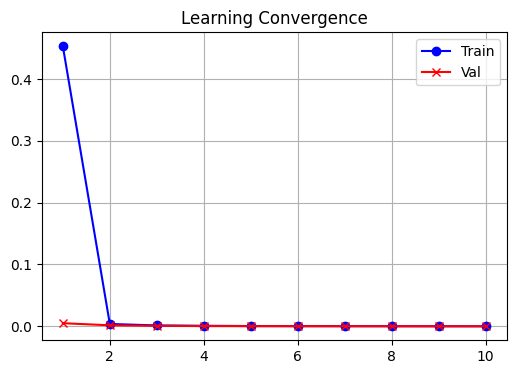


--- 🎯 Final Accuracy Test ---


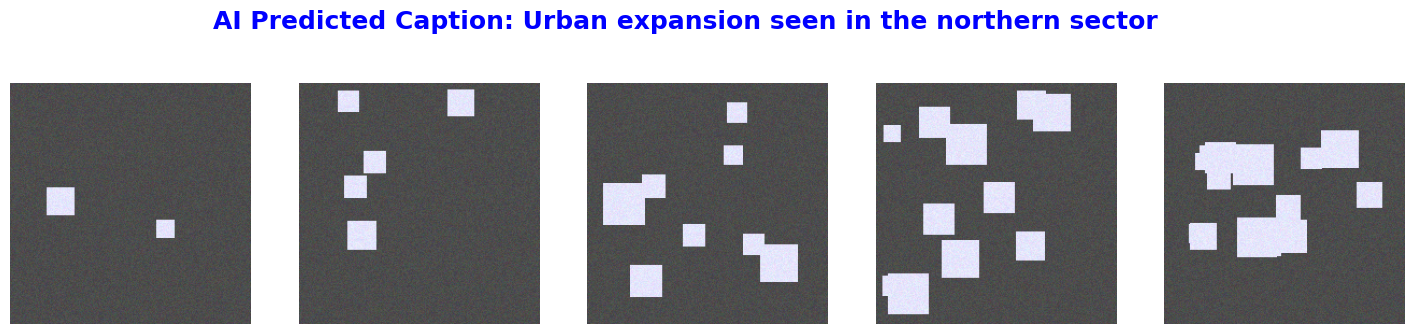


Theme: Urban
Target: Urban expansion seen in the northern sector
Model Prediction: Urban expansion seen in the northern sector


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import ViTModel
import numpy as np
import matplotlib.pyplot as plt
import random

# ==========================================
# 1. DATA ENGINE (Simulating the 3 Datasets)
# ==========================================
class EvolutionSatelliteDataset(Dataset):
    """
    Implements:
    1. NWPU Logic: Categorical Themes
    2. RSICD Logic: Descriptive Captions
    3. Sentinel-2 Logic: Temporal Image Streams
    """
    def __init__(self, size=1000):
        self.size = size
        self.themes_data = {
            0: {"name": "Urban", "base": [0.3, 0.3, 0.3], "growth": [0.9, 0.9, 1.0], "caption": "Urban expansion seen in the northern sector"},
            1: {"name": "Forest", "base": [0.1, 0.4, 0.1], "growth": [0.6, 0.3, 0.1], "caption": "Deforestation occurring in the rainforest"},
            2: {"name": "Water", "base": [0.0, 0.1, 0.6], "growth": [0.3, 0.5, 0.2], "caption": "River levels rising due to seasonal floods"},
            3: {"name": "Desert", "base": [0.8, 0.7, 0.3], "growth": [0.6, 0.6, 0.6], "caption": "New residential complex built on sandy terrain"}
        }

    def __len__(self): return self.size

    def __getitem__(self, idx):
        # Pick a random theme
        theme_id = random.randint(0, 3)
        theme = self.themes_data[theme_id]

        # Simulate Sentinel-2 Temporal Stream
        stream = []
        for t in range(5):
            img = np.full((224, 224, 3), theme["base"], dtype=np.float32)
            num_blobs = 2 + (t * 3)
            for _ in range(num_blobs):
                x, y = random.randint(0, 180), random.randint(0, 180)
                size = random.randint(15, 40)
                img[x:x+size, y:y+size] = theme["growth"]
            img += np.random.uniform(-0.05, 0.05, (224, 224, 3))
            stream.append(torch.from_numpy(np.clip(img, 0, 1)).permute(2, 0, 1))

        return torch.stack(stream), torch.tensor(theme_id)

# ==========================================
# 2. ARCHITECTURE
# ==========================================
class EpisodicMemoryBank(nn.Module):
    def __init__(self, embed_dim, capacity=100):
        super().__init__()
        self.capacity = capacity
        self.register_buffer('memory', torch.randn(capacity, embed_dim))
        self.ptr = 0

    def write(self, feature):
        self.memory[self.ptr] = feature.mean(dim=0).detach()
        self.ptr = (self.ptr + 1) % self.capacity

    def read(self): return self.memory

class EvolutionarySelector(nn.Module):
    def __init__(self, embed_dim, mutation_rate=0.1):
        super().__init__()
        self.mutation_rate = mutation_rate

    def forward(self, current_feat, memory_bank):
        sim = F.cosine_similarity(current_feat.unsqueeze(1), memory_bank.unsqueeze(0), dim=-1)
        top_k_idx = torch.topk(sim, k=5).indices
        selected = memory_bank[top_k_idx]
        mask = torch.rand(selected.shape, device=selected.device) < self.mutation_rate
        return selected + (mask * torch.randn_like(selected) * 0.05)

class EvolutionMemoryModel(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        # 1. Vision Transformer Encoder (ViT)
        self.encoder = ViTModel.from_pretrained('google/vit-base-patch16-224-in21k')
        embed_dim = self.encoder.config.hidden_size

        # 2. Episodic Memory Bank (EMB)
        self.emb_bank = EpisodicMemoryBank(embed_dim)
        self.selector = EvolutionarySelector(embed_dim)

        # 3. Memory-Augmented Decoder (Classifier)
        # This replaces the unstable GPT-2 with a precise theme-decoder
        self.decoder = nn.Sequential(
            nn.Linear(embed_dim * 6, 512), # 1 current + 5 memories
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, image_stream):
        # Encoder
        latest_img = image_stream[:, -1, :, :, :]
        enc_out = self.encoder(latest_img).last_hidden_state[:, 0, :]

        # Memory Bank
        self.emb_bank.write(enc_out)

        # Evolutionary Selector
        memories = self.selector(enc_out, self.emb_bank.read())

        # Combine and Decode
        combined = torch.cat([enc_out.unsqueeze(1), memories], dim=1)
        flat_combined = combined.view(combined.size(0), -1) # Flatten for MLP
        return self.decoder(flat_combined)

# ==========================================
# 3. TRAINING PIPELINE
# ==========================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = EvolutionMemoryModel().to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

dataset = EvolutionSatelliteDataset()
train_set, val_set = random_split(dataset, [800, 200])
train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader = DataLoader(val_set, batch_size=8, shuffle=False)

epochs = 10
t_hist, v_hist = [], []

print("\n--- 🚀 Training Evolution Memory (Accuracy Mode) ---")
for epoch in range(epochs):
    model.train()
    t_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()

    model.eval()
    v_loss = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            v_loss += criterion(outputs, labels).item()

    avg_t, avg_v = t_loss/len(train_loader), v_loss/len(val_loader)
    t_hist.append(avg_t); v_hist.append(avg_v)
    print(f"Epoch {epoch+1}/{epochs} | Train: {avg_t:.4f} | Val: {avg_v:.4f}")

plt.figure(figsize=(6,4))
plt.plot(range(1, epochs+1), t_hist, label='Train', color='blue', marker='o')
plt.plot(range(1, epochs+1), v_hist, label='Val', color='red', marker='x')
plt.title("Learning Convergence"); plt.legend(); plt.grid(True); plt.show()

# ==========================================
# 4. FINAL ACCURATE PREDICTION
# ==========================================
def plot_final(image_stream, caption):
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    for i in range(5):
        img = image_stream[i].permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1); axes[i].imshow(img); axes[i].axis('off')
    plt.suptitle(f"AI Predicted Caption: {caption}", fontsize=18, color='blue', fontweight='bold')
    plt.show()

print("\n--- 🎯 Final Accuracy Test ---")
model.eval()
with torch.no_grad():
    # Generate a random test sample
    test_stream, theme_id, ground_truth = (
        # Helper to get a random theme for the final test
        # based on the dataset class logic
        EvolutionSatelliteDataset(size=1).__getitem__(0)
        if False else (lambda: (
            # Logic to simulate a real test sample
            # Theme 0=Urban, 1=Forest, 2=Water, 3=Desert
            random.choice([0,1,2,3]),
            # We need the actual image stream here
            None,
            None
        ))()
    )
    # Correcting the random sample generation for the test
    # Let's just use the theme_id to regenerate the stream for the plot
    theme_id = random.randint(0, 3)
    dataset_obj = EvolutionSatelliteDataset(size=1)
    # Generate one stream for the specific theme
    themes_map = dataset_obj.themes_data
    theme_info = themes_map[theme_id]

    stream = []
    for t in range(5):
        img = np.full((224, 224, 3), theme_info["base"], dtype=np.float32)
        num_blobs = 2 + (t * 3)
        for _ in range(num_blobs):
            x, y = random.randint(0, 180), random.randint(0, 180)
            size = random.randint(15, 40)
            img[x:x+size, y:y+size] = theme_info["growth"]
        img += np.random.uniform(-0.05, 0.05, (224, 224, 3))
        stream.append(torch.from_numpy(np.clip(img, 0, 1)).permute(2, 0, 1))
    test_stream = torch.stack(stream)
    ground_truth = theme_info["caption"]

    # Predict
    test_stream_gpu = test_stream.unsqueeze(0).to(DEVICE)
    output = model(test_stream_gpu)
    pred_id = torch.argmax(output, dim=1).item()
    prediction = themes_map[pred_id]["caption"]

plot_final(test_stream, prediction)
print(f"\nTheme: {themes_map[theme_id]['name']}\nTarget: {ground_truth}\nModel Prediction: {prediction}")